# Project: Zürich wie neu

### 1. Introduction

This project investigates how urban issues are distributed across Zurich’s statistical neighborhoods and how these patterns have changed over time between 2014 and 2025. By combining spatial analysis with population normalization and temporal aggregation, this project aims to reveal not only in which neighborhoods most problems are, but also how their nature and intensity evolve.
The analysis integrates three key datasets: geolocated citizen reports from "Züri wie neu", statistical neighborhood boundaries, and population data. Together, they enable a multi-dimensional understanding of urban pressure, service demand, and neighborhood-level change.

#### 1.1. Research Question

How do citizen-reported urban issues in Zurich vary across neighborhoods in terms of intensity, evolution, and thematic composition between 2014 and 2025?


##### 1.1.1 Subquestions

**Question 1:** Which neighborhoods have the highest number of reports per capita?

**Question 2:**  Which neighborhoods have seen an increase or decrease in the number of reports between 2014 and 2025, and by how much?

**Question 3:** Which are the most common reported issue categories per neighborhood between 2014 and 2025?

**Question 4:**  Which issue has grown the fastest in each neighborhood between 2014 and 2025?


#### 1.2 Datasets

The datasets are form https://data.stadt-zuerich.ch/dataset: 

- Reports from Züri wie neu: https://data.stadt-zuerich.ch/dataset/geo_zueri_wie_neu

- Statistische Quartiere (Neighborhoods): https://data.stadt-zuerich.ch/dataset/geo_statistische_quartiere

- Population by neighbourhood https://data.stadt-zuerich.ch/dataset/bev_bestand_jahr_quartier_od3240

The datasets need to contain data from 2014-2025 (full years).

### 2. Input and Loading

#### 2.1. Imports

Here are of all imported libaries needed for this project.

In [307]:
# import libaries
import geopandas as gpd
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import mapclassify # for classifying the choropleth map


#### 2.2. Path Settings

Here are all paths listed for raw and processed data and also for outputs.

In [308]:
# paths to raw datasets 
raw_path_neighborhoods = Path("../data/raw/neighborhoods/statistische_quartiere.gpkg")
raw_path_reports = Path("../data/raw/zueri-wie-neu-reports/reports.gpkg")
raw_path_population_zh = Path("../data/raw/population.csv")

# paths to processed datasets 
processed_path_neighborhoods = Path("../data/processed/neighborhoods_cleaned.gpkg")
processed_path_reports = Path("../data/processed/reports_cleaned.gpkg")
processed_path_population_zh = Path("../data/processed/population_cleaned.csv")

# paths to output maps 
output_path_normalized_reports = Path("../outputs/map/normalized_reports_zurich_2014_2025_map.png")
output_path_reports_growth_map = Path("../outputs/map/reports_growth_map_zurich_2014_2025_map.png")
output_path_common_issue_map = Path("../outputs/map/reports_common_issue_map_zurich_2014_2025_map.png")
output_path_fast_growing_issue = Path("../outputs/map/fast_growing_issue_zurich_2014_2025_map.png")

# paths to output bar plot 
output_path_normalized_reports_bar = Path("../outputs/plot/normalized_reports_bar_zurich_2014_2025_map.png")

#### 2.3. Loading and Normalizing Functions

Here are all functions used for this project.

In [309]:
# functions

# loading data while veryfying if file exists
def load_spatial_data(filepath, layer=None):
    """
    Safely loads spatial data after verifying the file exists.
    Supports CSV and common geospatial formats (GeoPackage, Shapefile, GeoJSON).

    Parameters:

    filepath: str or Path
        Path to the input file.
    layer: str, optional
        Layer name for formats that support multiple layers (e.g., GeoPackage).

        
    Returns:

    DataFrame or GeoDataFrame
        Loaded dataset depending on file type.

        
    Raises:

    FileNotFoundError
        If the file does not exist.
    ValueError
        If the file extension is unsupported.
    """
    
    data_path = Path(filepath)
    
    # Defensive check: Does the file exist, and is it actually a file?
    if not data_path.is_file():
        raise FileNotFoundError(f"Missing data, could not find: {data_path.absolute()}")
    
    if data_path.suffix == ".csv":
        return pd.read_csv(data_path)

    elif data_path.suffix in [".gpkg", ".shp", ".geojson"]: #only .gpkg is (besides .csv) in this project
        return gpd.read_file(data_path, layer=layer)

    else:
        raise ValueError(f"Unsupported file type: {data_path.suffix}")





# plotting a choropleth map
def create_choropleth(
    gdf,
    column,
    title,
    legend_title,
    output_path,
    k=5,
    classification="NaturalBreaks",
    cmap="OrRd"
):
    """
    Create and save a choropleth map from a GeoDataFrame.

    Supports both categorical and numerical data. Numerical data
    can be classified using Natural Breaks, Quantiles, or Equal Interval.

    
    Parameters:

    gdf: GeoDataFrame
            Input geospatial data.
    column: str
            Column to visualize.
    title: str
            Map title.
    legend_title: str
            Legend title (used for numerical maps).
    output_path: str or Path
            File path for saving the figure.
    k: int, default=5
            Number of classes for numerical classification.
    classification: {"NaturalBreaks", "Quantiles", "EqualInterval"}, default="NaturalBreaks"
            Classification method for numerical data.
    cmap: str, default="OrRd"
            Matplotlib colormap.

            
    Returns:

    classifier or None
            Classification object for numerical data, otherwise None.
    """

    # automatically detect categorical data
    categorical = gdf[column].dtype == "object"

    # so a categorical map can never be treated as a numerical map
    if gdf[column].dtype == "object":
        categorical = True


    # copy because copy_gdf["class"] = classifier.yb  would change the original dataset
    copy_gdf = gdf.copy()

    # plot the map
    fig, ax = plt.subplots(figsize=(11, 8))

    if categorical:
        copy_gdf.plot(
            column=column,
            categorical=True,
            legend=True,
            cmap=cmap,
            ax=ax,
            edgecolor="black",
            missing_kwds={
                "color": "lightgrey",
                "label": "No data"
            }
        )
        
        classifier = None  # nothing to return

    else:

        # Classification
        if classification == "NaturalBreaks":
            classifier = mapclassify.NaturalBreaks(copy_gdf[column], k=k)
        elif classification == "Quantiles":
            classifier = mapclassify.Quantiles(copy_gdf[column], k=k)
        elif classification == "EqualInterval":
            classifier = mapclassify.EqualInterval(copy_gdf[column], k=k)
        else:
            raise ValueError("Unknown classification method")

        copy_gdf.plot(
            column=column,
            scheme=classification,
            k=k,
            cmap=cmap,
            legend=True,
            ax=ax,
            edgecolor="black",
            missing_kwds={
                "color": "lightgrey",
                "label": "No data"
            },
            legend_kwds={
                "title": legend_title,
                "loc": "lower left"
            }
        )


    
    # set a title and plot without axis
    ax.set_title(title)
    ax.set_axis_off()


    # Save the maps to the output folder via output_path
    fig.savefig(output_path, dpi=400) # dpi is the resolution 
    plt.show()

    return classifier

#### 2.3. Loading the Datasets

(Note: There are two files calld metadata_neighborhoods and metadata_reports in the raw data folder (data/raw/neighborhoods or zueri-wie-neu-reports) which provide more information about the datasets and attributes.)

First, we have to chose the relevant layer for the neighborhoods dataset.

1. ADM_STATISTISCHE_QUARTIERE_B_P
    Label points for statistical neighborhoods. This point layer contains information used for optimal placement of labels on maps.

2. ADM_STATISTISCHE_QUARTIERE_MAP
    This layer can be used for data visualization and cartographic representations. It includes the complete attribute table and is generalized, meaning the geometry has been simplified and does not represent the exact official surveyed boundaries.

3. ADM_STATISTISCHE_QUARTIERE_V
    This layer contains the precise boundary geometries of the statistical neighborhoods and includes the full attribute table. It is suitable for calculating areas or performing spatial joins, but it is not suitable for cartographic visualization.

Given these explanations of each layer we choose the stzh.adm_statistische_quartiere_v layer.

Now, we can load all datasets.

In [310]:
# try to load the neighborhood dataset with the relevant layer
try:
    neighborhoods = load_spatial_data(raw_path_neighborhoods, layer= "stzh.adm_statistische_quartiere_v") # neighborhoods of Zurich
except Exception as e:
    print(e)
assert len(neighborhoods) > 0, "Failed to load file."

# try to load the reports dataset
try:
    reports =load_spatial_data(raw_path_reports) # reports from Züri Wie Neu
except Exception as e:
    print(e)
assert len(reports) > 0, "Failed to load file."

# try to load the population dataset
try:
    population_zh = load_spatial_data(raw_path_population_zh) # population of neighborhoods of Zurich
except Exception as e:
    print(e)
assert len(population_zh) > 0, "Failed to load file."

### 3. Dataset Exploration

We want to have a look at the datasets and check for the correct data types, shapes, coordinate system and other important information.

#### 3.1. Explore the Dataset Neighborhoods

We want to check for the correct data types, shapes and bounds.

In [311]:
# check for correct data types and shape
print(neighborhoods.info()) # all correct

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   objid     34 non-null     object  
 1   objectid  34 non-null     int32   
 2   qname     34 non-null     object  
 3   qnr       34 non-null     int32   
 4   kname     34 non-null     object  
 5   knr       34 non-null     int32   
 6   geometry  34 non-null     geometry
dtypes: geometry(1), int32(3), object(3)
memory usage: 1.6+ KB
None


In [312]:
# have a look at what is inside neighborhoods (columns and entries)
display(neighborhoods.head())

,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


In [313]:
# coordinate system used for neighborhoods dataset
print(neighborhoods.crs)

EPSG:2056


In [314]:
# check bounds
print(neighborhoods.total_bounds)

[2676224.694 1241584.105 2689665.812 1254306.233]


#### 3.2. Explore the Dataset Reports

We want to check for the correct data types, shapes and bounds.

In [315]:
# check for shape and correct data types
print(reports.info()) # all correct

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73149 entries, 0 to 73148
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              73149 non-null  int32         
 1   service_request_id    73149 non-null  object        
 2   requested_datetime    73149 non-null  datetime64[ms]
 3   agency_sent_datetime  72318 non-null  datetime64[ms]
 4   updated_datetime      73149 non-null  datetime64[ms]
 5   e                     73149 non-null  int32         
 6   n                     73149 non-null  int32         
 7   service_code          73149 non-null  object        
 8   service_name          73149 non-null  object        
 9   status                73149 non-null  object        
 10  userid                73149 non-null  int32         
 11  title                 73149 non-null  object        
 12  detail                73149 non-null  object        
 13  media_ur

In [316]:
# have a look at what is inside reports (columns and entries)
display(reports.head())

,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,userid,title,detail,media_url,interface_used,service_notice,description,url,geometry
0,1,1,2013-03-14 15:16:15,2013-04-04 07:25:05,2013-04-12 07:59:30,2678968,1247548,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Asp,Auf dem Asphalt des Bürgersteigs hat es eine E...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,https://www.zueriwieneu.ch/report/1,POINT (2678968 1247548)
1,2,2,2013-03-14 15:17:57,2013-03-26 14:05:05,2013-04-12 08:00:22,2680746,1249916,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Vermessungs,Vermessungspunkt ist nicht mehr bündig mit dem...,,Web interface,Diese Reparatur wird von uns in den kommenden ...,Vermessungs: Vermessungspunkt ist nicht mehr b...,https://www.zueriwieneu.ch/report/2,POINT (2680746 1249916)
2,3,4,2013-03-15 09:14:16,2013-03-15 09:55:05,2013-04-12 08:08:10,2684605,1251431,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Beim Trotto,Beim Trottoir sind einige Randsteine defekt un...,https://www.zueriwieneu.ch/photo/4.0.jpeg?bfbb...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Beim Trotto: Beim Trottoir sind einige Randste...,https://www.zueriwieneu.ch/report/4,POINT (2684605 1251431)
3,4,5,2013-03-15 09:17:15,2013-03-20 10:05:05,2013-04-12 08:09:05,2681754,1250376,Strasse/Trottoir/Platz,Strasse/Trottoir/Platz,fixed - council,16624,Auf dem Par,Auf dem Parkplatz beim Waidspital sind einige ...,https://www.zueriwieneu.ch/photo/5.0.jpeg?e309...,Web interface,Diese Reparatur wird von uns in den kommenden ...,Auf dem Par: Auf dem Parkplatz beim Waidspital...,https://www.zueriwieneu.ch/report/5,POINT (2681754 1250376)
4,5,6,2013-03-15 10:36:53,2013-04-22 18:25:05,2013-04-23 13:50:33,2683094,1247762,Abfall/Sammelstelle,Abfall/Sammelstelle,fixed - council,16624,Arbeitskist,Arbeitskiste ist rund herum verschmiert,https://www.zueriwieneu.ch/photo/6.0.jpeg?8e65...,Web interface,Dieses Graffiti wird von uns in den kommenden ...,Arbeitskist: Arbeitskiste ist rund herum versc...,https://www.zueriwieneu.ch/report/6,POINT (2683094 1247762)


In [317]:
# because there are so many columns, here an overview 
print(reports.columns)

Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry'],
      dtype='object')


In [318]:
# coordinate system used for reports dataset
print(reports.crs)

EPSG:2056


In [319]:
# check bounds
print(reports.total_bounds)

[2677064. 1241838. 2689602. 1254299.]


#### 3.3. Explore the Dataset Population of Zurich

We want to check for the correct data types, shapes and bounds.

In [320]:
# check for shape and correct data types
print(population_zh.info()) # all correct

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2785 entries, 0 to 2784
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   StichtagDatJahr  2785 non-null   int64 
 1   QuarSort         2785 non-null   int64 
 2   QuarLang         2785 non-null   object
 3   AnzBestWir       2785 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 87.2+ KB
None


In [321]:
# have a look at what is inside population (columns and entries)
print(population_zh.head())

   StichtagDatJahr  QuarSort QuarLang  AnzBestWir
0             2025        11  Rathaus        3252
1             2024        11  Rathaus        3260
2             2023        11  Rathaus        3343
3             2022        11  Rathaus        3330
4             2021        11  Rathaus        3275


### 4. Preparation and Cleaning 

Clean the datasets so that they include only important information/ and save it to the processed data folder.

#### 4.1. Preparating and Cleaning Neighborhoods Dataset

Check for NaNs and select the important attributes only.

In [322]:
# check for NaNs in neighborhoods
print(neighborhoods.isna().sum()) # no NaNs

objid       0
objectid    0
qname       0
qnr         0
kname       0
knr         0
geometry    0
dtype: int64


In [323]:
# select important attributes
neighborhoods_cleaned = neighborhoods[[
    'qname',
    'kname',
    'geometry'
]]

In [324]:
# save file in processed data folder
neighborhoods_cleaned.to_file(processed_path_neighborhoods)

#### 4.2. Preparating and Cleaning Reports Dataset

Check for NaNs and select the important attributes only and rename them in English if needed. Also, we only want the years 2014-2025 (full years) because incomplete years do not provide a meaningful basis for comparison when analyzing the data across different years. Moreover, we create the attribute "year" from the requested date beacuse we do not need months or time for our later analysis.

In [325]:
# check for NaNs in reports
print(reports.isna().sum()) # NaNs of agency sent datetime are irrelevant for this analysis

objectid                  0
service_request_id        0
requested_datetime        0
agency_sent_datetime    831
updated_datetime          0
e                         0
n                         0
service_code              0
service_name              0
status                    0
userid                    0
title                     0
detail                    0
media_url                 0
interface_used            0
service_notice            0
description               0
url                       0
geometry                  0
dtype: int64


In [326]:
# rename the service categories in English 
reports["service_name"] = reports["service_name"].replace({
    "Abfall/Sammelstelle": "Waste / Collection point",
    "Beleuchtung/Uhren": "Lighting / Public clocks",
    "Graffiti": "Graffiti",
    "Signalisation/Lichtsignal": "Traffic signals & signage",
    "Grünflächen/Spielplätze": "Green spaces / Playgrounds",
    "Strasse/Trottoir/Platz": "Roads / Sidewalks / Public spaces",
    "Brunnen/Hydranten": "Water infrastructure",
    "VBZ/ÖV": "Public transport"
})

In [327]:
# only the year is relevant in the requested datetime so we make a new attribute called "year"
reports["year"] = (
    reports["requested_datetime"].dt.year
)
print(reports.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 73149 entries, 0 to 73148
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              73149 non-null  int32         
 1   service_request_id    73149 non-null  object        
 2   requested_datetime    73149 non-null  datetime64[ms]
 3   agency_sent_datetime  72318 non-null  datetime64[ms]
 4   updated_datetime      73149 non-null  datetime64[ms]
 5   e                     73149 non-null  int32         
 6   n                     73149 non-null  int32         
 7   service_code          73149 non-null  object        
 8   service_name          73149 non-null  object        
 9   status                73149 non-null  object        
 10  userid                73149 non-null  int32         
 11  title                 73149 non-null  object        
 12  detail                73149 non-null  object        
 13  media_ur

In [328]:
# filter for reports during full years (2014-2025)
reports_filtered_years = reports[
    (reports['year'] >= 2014) &
    (reports['year'] <= 2025)
]
print(reports_filtered_years.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   objectid              66345 non-null  int32         
 1   service_request_id    66345 non-null  object        
 2   requested_datetime    66345 non-null  datetime64[ms]
 3   agency_sent_datetime  65601 non-null  datetime64[ms]
 4   updated_datetime      66345 non-null  datetime64[ms]
 5   e                     66345 non-null  int32         
 6   n                     66345 non-null  int32         
 7   service_code          66345 non-null  object        
 8   service_name          66345 non-null  object        
 9   status                66345 non-null  object        
 10  userid                66345 non-null  int32         
 11  title                 66345 non-null  object        
 12  detail                66345 non-null  object        
 13  media_url  

In [329]:
# selecting important columns only
reports_cleaned = reports_filtered_years[[
    'year',
    'service_name',
    'geometry'
]]
print(reports_cleaned.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   year          66345 non-null  int32   
 1   service_name  66345 non-null  object  
 2   geometry      66345 non-null  geometry
dtypes: geometry(1), int32(1), object(1)
memory usage: 1.8+ MB
None


In [330]:
# save file in processed data folder
reports_cleaned.to_file(processed_path_reports)

#### 4.3. Preparating and Cleaning Population of Zurich Dataset

Check for NaNs and select the important attributes only and rename them in English.

In [331]:
# check for NaNs in population
print(population_zh.isna().sum())

StichtagDatJahr    0
QuarSort           0
QuarLang           0
AnzBestWir         0
dtype: int64


In [332]:
# select important columns only
popolation_filtered = population_zh[[
    'StichtagDatJahr',
    'QuarLang',
    'AnzBestWir'
]]
popolation_filtered

,StichtagDatJahr,QuarLang,AnzBestWir
0,2025,Rathaus,3252
1,2024,Rathaus,3260
2,2023,Rathaus,3343
3,2022,Rathaus,3330
4,2021,Rathaus,3275
...,...,...,...
2780,1974,Hirzenbach,12759
2781,1973,Hirzenbach,12975
2782,1972,Hirzenbach,13286
2783,1971,Hirzenbach,13627


In [333]:
# rename columns in English
population_cleaned = popolation_filtered.rename(columns={
    'StichtagDatJahr':'year',
    'QuarLang':'qname',
    'AnzBestWir':'population'
})
population_cleaned

,year,qname,population
0,2025,Rathaus,3252
1,2024,Rathaus,3260
2,2023,Rathaus,3343
3,2022,Rathaus,3330
4,2021,Rathaus,3275
...,...,...,...
2780,1974,Hirzenbach,12759
2781,1973,Hirzenbach,12975
2782,1972,Hirzenbach,13286
2783,1971,Hirzenbach,13627


In [334]:
# save file in processed data folder without index (utf-8-sig for umlauts) 
population_cleaned.to_csv(processed_path_population_zh, index=False, encoding="utf-8-sig") 

### 5. Spatial Join

Reports need to be joined to neighborhoods as they only have a point location.
Polulation has already a correct attribute for neighborhoods.

#### 5.1. Spatial Join Reports Dataset with Neighborhoods Dataset

In [335]:
# join reports accordingly within which neighborhood they are
reports_joined_neighborhoods = gpd.sjoin(
    reports_cleaned,
    neighborhoods_cleaned,
    how="left",
    predicate="within")

# have a look at the joined dataset
print(reports_joined_neighborhoods.info())

# check if every report is in assigned to a neigborhood
print(reports_joined_neighborhoods.isna().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 66345 entries, 188 to 69265
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   year          66345 non-null  int32   
 1   service_name  66345 non-null  object  
 2   geometry      66345 non-null  geometry
 3   index_right   66345 non-null  int64   
 4   qname         66345 non-null  object  
 5   kname         66345 non-null  object  
dtypes: geometry(1), int32(1), int64(1), object(3)
memory usage: 3.3+ MB
None
year            0
service_name    0
geometry        0
index_right     0
qname           0
kname           0
dtype: int64


### 6. Analysis of the Questions

#### 6.1. Question 1: Which neighborhoods have the highest number of reports per capita?

We want a choropleth map which should show where the high numbers of reports per capita are and identify the neighborhood with the highest number.

##### 6.1.1 Absolute counts of reports per neighborhood

Count reports number per year and per neighborhood. 

In [336]:
# Ensure reports_joined_neighborhoods has required column
assert "qname" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (qname)."
assert "qname" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (year)."

reports_per_neighborhood = (
    reports_joined_neighborhoods
    .groupby(["qname", "year"])
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)
# Validate result is not empty
assert len(reports_per_neighborhood) > 0, "Aggregation failed: no neighborhood reports found."

#have a look at reports_per_neighborhood
print(reports_per_neighborhood.info())
print(reports_per_neighborhood.head())


<class 'pandas.core.frame.DataFrame'>
Index: 408 entries, 203 to 204
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   qname         408 non-null    object
 1   year          408 non-null    int32 
 2   report_count  408 non-null    int64 
dtypes: int32(1), int64(1), object(1)
memory usage: 11.2+ KB
None
           qname  year  report_count
203  Langstrasse  2025          1200
202  Langstrasse  2024          1020
334     Sihlfeld  2024           909
335     Sihlfeld  2025           795
201  Langstrasse  2023           759


We see that the report count for Langstrasse 2025 is the heighest.

##### 6.1.2 Normalized Counts of reports per neighborhood
We want to normalize the report counts per neighborhood and year in each neighborhood. Therefore, we first need to merge the population dataset and then do the normalization.

In [337]:
# we need to merge the population to noramlize the reports
normalized_reports = reports_per_neighborhood.merge(
    population_cleaned,
    on=["year", "qname"],
    how="left"
)
assert normalized_reports["population"].notna().all(), \
    "Missing population values after merge"


In [338]:
# create an attribute including the per 1000 normalized reports value
normalized_reports["reports_per_1000"] = (
    normalized_reports["report_count"] /
    normalized_reports["population"]
) * 1000 #to get a greater and more readable number

# have a look at the normalized reports 
# and where the highest reports of a year is per neighborhood 
print(normalized_reports.sort_values("reports_per_1000", ascending=False))


                    qname  year  report_count  population  reports_per_1000
54                   City  2025           288         769        374.512354
78            Hochschulen  2025           243         688        353.197674
97            Hochschulen  2024           213         684        311.403509
79                   City  2024           242         785        308.280255
141           Hochschulen  2023           159         695        228.776978
..                    ...   ...           ...         ...               ...
401               Saatlen  2016            16        8283          1.931667
394  Schwamendingen-Mitte  2015            21       11315          1.855943
395            Hirzenbach  2015            21       11930          1.760268
407              Leimbach  2014             7        5936          1.179245
406               Saatlen  2015            10        8508          1.175364

[408 rows x 5 columns]


Now, looking at the normalized data, City 2025 has the most reports per 1000 neighborhood residents.

##### 6.1.3 Choropleth Map of the Average Normalized Report Number per Neighborhood Over All Years

We now want to show a choropleth map to see which neighborhood has the most reports normalized by population over these 12 years (2014-2025). To do so, we take the average number of reports a neighborhood had in these years.

In [339]:
# calculate average reports for each neighborhood
average_nomalized_reports = (
    normalized_reports
    .groupby("qname", as_index=False)["reports_per_1000"]
    .mean()
)
# where the highest average of normalized reports number are over all years
print(average_nomalized_reports.sort_values("reports_per_1000", ascending=False))

                   qname  reports_per_1000
4                   City        162.335712
13           Hochschulen        151.834887
18             Lindenhof         84.009180
16           Langstrasse         40.938799
22               Rathaus         32.894096
30                  Werd         25.424395
5                   Enge         21.327284
6            Escher Wyss         19.234522
27              Sihlfeld         18.710600
9          Gewerbeschule         17.703974
26               Seefeld         17.659010
10                  Hard         16.896043
31             Wipkingen         14.270506
11            Hirslanden         13.966054
14             Hottingen         13.174428
29               Weinegg         11.375588
7               Fluntern         11.174375
28           Unterstrass         11.053516
19             Mühlebach         10.972171
33           Wollishofen         10.922438
20            Oberstrass         10.669283
2           Alt-Wiedikon         10.574806
8          

Here again, City has the most normalized reports numbers over all years.

In [340]:
# merge to neighborhoods to get the geometry (polygon) of the neighborhoods
normalized_reports_map = neighborhoods_cleaned.merge(
    average_nomalized_reports,
    on="qname",
    how="left"
)

# have a look at normalized reports with the geometry of neighborhoods
print(normalized_reports_map.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   qname             34 non-null     object  
 1   kname             34 non-null     object  
 2   geometry          34 non-null     geometry
 3   reports_per_1000  34 non-null     float64 
dtypes: float64(1), geometry(1), object(2)
memory usage: 1.2+ KB
None


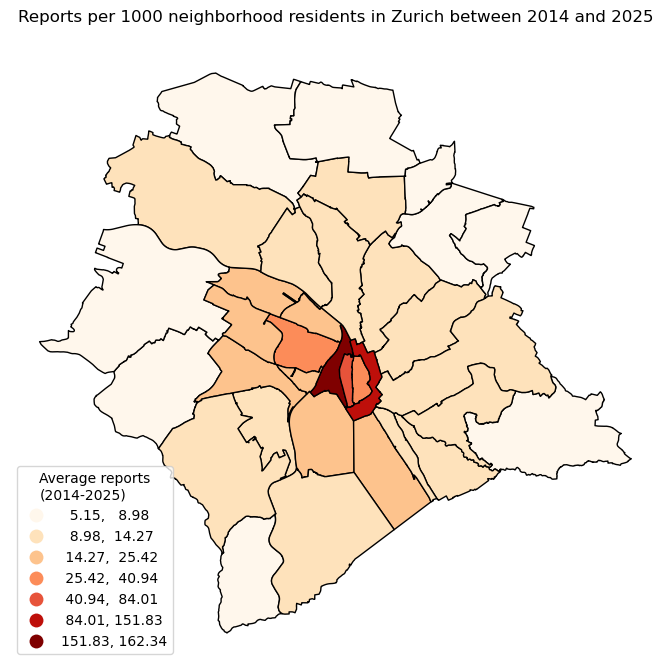

NaturalBreaks

    Interval       Count
------------------------
[  5.15,   8.98] |     9
(  8.98,  14.27] |    13
( 14.27,  25.42] |     7
( 25.42,  40.94] |     2
( 40.94,  84.01] |     1
( 84.01, 151.83] |     1
(151.83, 162.34] |     1

In [341]:
create_choropleth(
    normalized_reports_map,
    "reports_per_1000",
    title = "Reports per 1000 neighborhood residents in Zurich between 2014 and 2025",
    legend_title = "Average reports\n(2014-2025)",
    output_path = output_path_normalized_reports,
    k=7,
    classification="NaturalBreaks"
)

We can also show the normalized reports of all neighborhoods (2014-2025) with a bar plot.

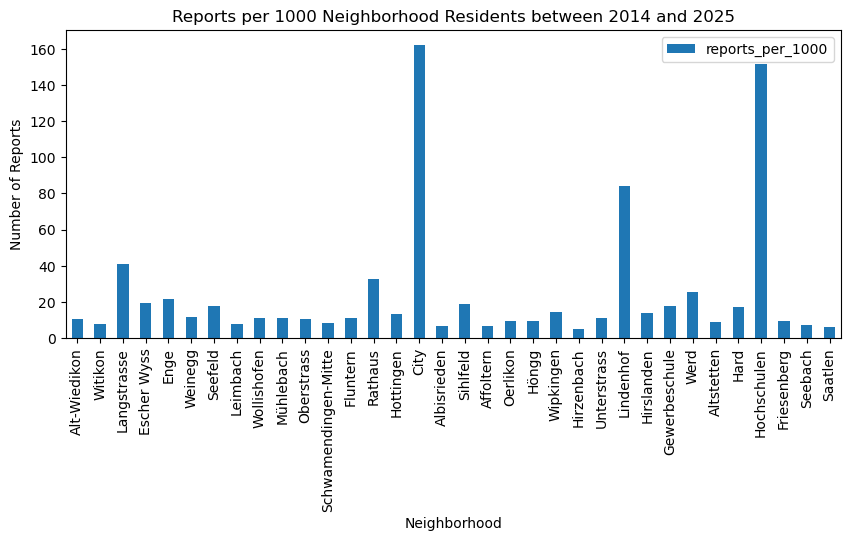

<Figure size 640x480 with 0 Axes>

In [342]:
# plot the reports per neighborhood in a bar plot
fig, ax = plt.subplots(figsize=(10, 4))

normalized_reports_map.plot(
    kind="bar",
    x="qname",
    y="reports_per_1000",
    ax=ax
)

ax.set_title("Reports per 1000 Neighborhood Residents between 2014 and 2025")
ax.set_xlabel("Neighborhood")
ax.set_ylabel("Number of Reports")

plt.show()

# save plot
plt.savefig(output_path_normalized_reports_bar)


So, City and Hochschulen have the most reports per 1000 neighborhood residents.

#### 6.2. Question 2: Which neighborhoods have seen an increase or decrease in the number of reports between 2014 and 2025, and by how much?

We want a choropleth map which should show where the absolut numbers of reports increased and by how much (color).

##### 6.2.1 Absolute counts of reports per neighborhood and the difference between 2014 and 2025

We already counted the reports number in the question before in "reports_per_neighborhood". Therefore, we only need to reshape reports_per_neighborhood. We want a table with report count values for each neighborhood (row) and each year (coulumn).

In [343]:
#create a table with report count values
pivot_reports = reports_per_neighborhood.pivot(
    index="qname",
    columns="year",
    values="report_count"
)
print(pivot_reports.isna().sum())
print(pivot_reports.info())
print(pivot_reports.head())

year
2014    0
2015    0
2016    0
2017    0
2018    0
2019    0
2020    0
2021    0
2022    0
2023    0
2024    0
2025    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, Affoltern to Wollishofen
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   2014    34 non-null     int64
 1   2015    34 non-null     int64
 2   2016    34 non-null     int64
 3   2017    34 non-null     int64
 4   2018    34 non-null     int64
 5   2019    34 non-null     int64
 6   2020    34 non-null     int64
 7   2021    34 non-null     int64
 8   2022    34 non-null     int64
 9   2023    34 non-null     int64
 10  2024    34 non-null     int64
 11  2025    34 non-null     int64
dtypes: int64(12)
memory usage: 3.5+ KB
None
year          2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  \
qname                                                                      
Affoltern       65    52    82   117   110   195   182   202

Now, we calculate the difference of report counts between 2014 and 2025.

In [344]:
# difference of report counts 2014 and 2025
pivot_reports["reports_growth"] = pivot_reports[2025] - pivot_reports[2014]

##### 6.2.2 Map of increase or decrease in report number

First, we need to merge it to the neighborhoods dataset to get the polygon of the neighborhoods.

In [345]:
# merge to the cleaned neighborhoods
reports_growth_map = neighborhoods_cleaned.merge(
    pivot_reports["reports_growth"].reset_index(), # reset to get again a normal column
    on="qname"
)

We can map the result using the helper function created for mapping.

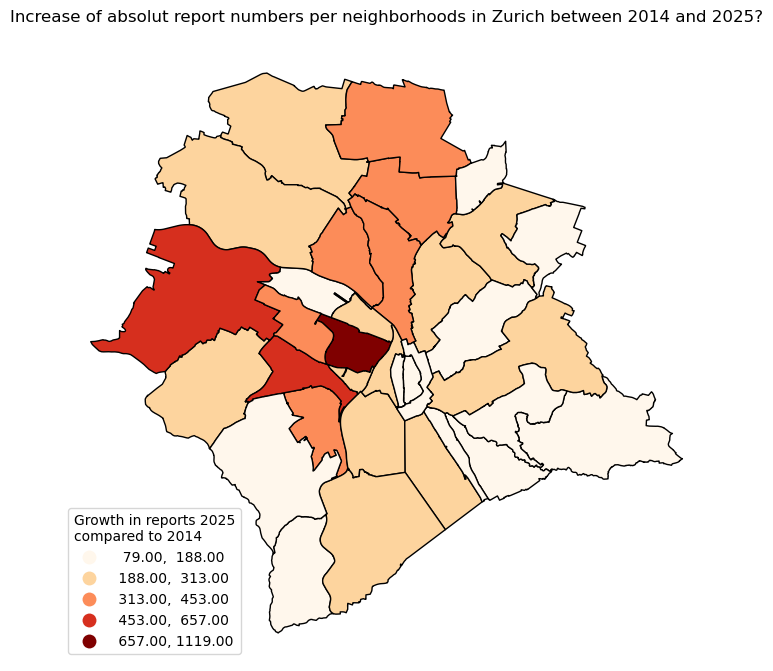

NaturalBreaks

     Interval        Count
--------------------------
[  79.00,  188.00] |    13
( 188.00,  313.00] |    12
( 313.00,  453.00] |     6
( 453.00,  657.00] |     2
( 657.00, 1119.00] |     1

In [346]:
# map the growth map
create_choropleth(
    gdf = reports_growth_map,
    column = "reports_growth",
    title = "Increase of absolut report numbers per neighborhoods in Zurich between 2014 and 2025?",
    legend_title = "Growth in reports 2025\ncompared to 2014 ",
    output_path = output_path_reports_growth_map,
    classification = "NaturalBreaks"
)

So, in Langstrasse, the number of reports has highly increased.

#### 6.3. Question 3: Which are the most common reported issue categories per neighborhood between 2014 and 2025?

We want a choropleth map which should show what the most common issue categories per neighborhood are.

##### 6.3.1 Find the most common issue per category and neighborhood

Count issue number per service name (categorized issue) and per neighborhood and name it issue_count.

In [347]:
# Ensure reports_joined_neighborhoods has required column
assert "qname" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (qname)."
assert "service_name" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (service_name)."

issue_per_neighborhood = (
    reports_joined_neighborhoods
    .groupby(["qname", "service_name"])
    .size()
    .reset_index(name="issue_count")
)
# Validate result is not empty
assert len(issue_per_neighborhood) > 0, "Aggregation failed: no service name (issue) per neighborhood found."


#have a look at info of reports_per_neighborhood
print(issue_per_neighborhood.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   qname         340 non-null    object
 1   service_name  340 non-null    object
 2   issue_count   340 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 8.1+ KB
None


Now, find the most common issue.

In [348]:
# select the row with the highest issue_count for each neighborhood
most_common_issue = issue_per_neighborhood.loc[
    issue_per_neighborhood.groupby("qname")["issue_count"].idxmax()
]
print(most_common_issue.isna().sum())
print(pivot_reports.info())
print(pivot_reports.head())

qname           0
service_name    0
issue_count     0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 34 entries, Affoltern to Wollishofen
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   2014            34 non-null     int64
 1   2015            34 non-null     int64
 2   2016            34 non-null     int64
 3   2017            34 non-null     int64
 4   2018            34 non-null     int64
 5   2019            34 non-null     int64
 6   2020            34 non-null     int64
 7   2021            34 non-null     int64
 8   2022            34 non-null     int64
 9   2023            34 non-null     int64
 10  2024            34 non-null     int64
 11  2025            34 non-null     int64
 12  reports_growth  34 non-null     int64
dtypes: int64(13)
memory usage: 3.7+ KB
None
year          2014  2015  2016  2017  2018  2019  2020  2021  2022  2023  \
qname                                               

##### 6.3.2 Map the most common issue per category and neighborhood

First, merge most common issue to neighborhoods to get its polygon.

In [349]:
# merge the most common isue to neighborhoods
# to get the geometry (polygon) of the neighborhoods
issue_map_gdf = neighborhoods_cleaned.merge(
    most_common_issue,
    on="qname",
    how="left"
)

Map the most common issue.

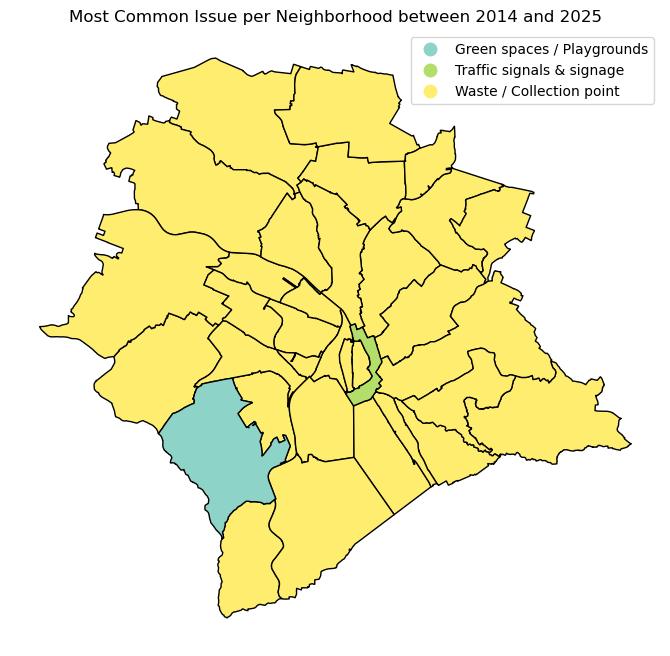

In [350]:
# map the most common issue per neighborhood
create_choropleth(
    gdf = issue_map_gdf,
    column = "service_name",
    title = "Most Common Issue per Neighborhood between 2014 and 2025",
    legend_title = "Issue Type",
    output_path = output_path_common_issue_map,
    cmap = "Set3"
)

Interestingly, the most neighborhoods share the most common issue (waste/collection point of waste). Hochschulen and Friesenberg have another most common issue. 

#### 6.4. Question 4: Which issue has grown the fastest in each neighborhood between 2014 and 2025?

We want a choropleth map which should show what the fastest growing issue per neighborhood is.

##### 6.4.1 Find the fastest growing issue per neighborhood

First, count the issues per category, year and neighborhood and name it waste_count.

In [351]:
# Ensure reports_joined_neighborhoods has required column
assert "qname" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (qname)."
assert "service_name" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (service_name)."
assert "year" in reports_joined_neighborhoods.columns, "Missing reports_joined_neighborhoods column (year)."

trend_waste = (
    reports_joined_neighborhoods
    .groupby(["qname", "service_name", "year"])
    .size()
    .reset_index(name="waste_count")
)
# Validate result is not empty
assert len(trend_waste) > 0, "Aggregation failed: no service name (issue) per neighborhood found."


#have a look at info of reports_per_neighborhood
print(trend_waste.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3406 entries, 0 to 3405
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   qname         3406 non-null   object
 1   service_name  3406 non-null   object
 2   year          3406 non-null   int32 
 3   waste_count   3406 non-null   int64 
dtypes: int32(1), int64(1), object(2)
memory usage: 93.3+ KB
None


We need to reshape trend_waste. Therefore, we create a table where each row represents a combination of neighborhood and issue category, and each column represents a year with corresponding waste count.

In [352]:
# cearte table with waste count
pivot_waste = trend_waste.pivot_table(
    index=["qname", "service_name"],
    columns="year",
    values="waste_count",
).reset_index() # reset to get back to normal columns

print(pivot_waste.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   qname         340 non-null    object 
 1   service_name  340 non-null    object 
 2   2014          187 non-null    float64
 3   2015          208 non-null    float64
 4   2016          237 non-null    float64
 5   2017          253 non-null    float64
 6   2018          260 non-null    float64
 7   2019          300 non-null    float64
 8   2020          315 non-null    float64
 9   2021          327 non-null    float64
 10  2022          325 non-null    float64
 11  2023          329 non-null    float64
 12  2024          332 non-null    float64
 13  2025          333 non-null    float64
dtypes: float64(12), object(2)
memory usage: 37.3+ KB
None


We now want the difference between 2014 and 2025. Afterwards, for each neighborhood, we want the service category that experienced the strongest increase between 2014 and 2025.

In [353]:
# calculate the difference
pivot_waste["waste_growth"] = pivot_waste[2025] - pivot_waste[2014]

In [354]:
# neighborhood with the strongest increase in waste_growth
top_growth = pivot_waste.reset_index().loc[
    pivot_waste.groupby("qname")["waste_growth"].idxmax()
]

##### 6.4.2 Map the fastest growing issue per neighborhood

We merge top_growth and neighborhoods to get the polygon from neighborhoods.

In [355]:
# merge with neighborhood to get the polyfon
fast_growing_issue_map = neighborhoods_cleaned.merge(
    top_growth[["qname", "service_name"]],
    on="qname",
    how="left"
)

Now, we can map the top growth.

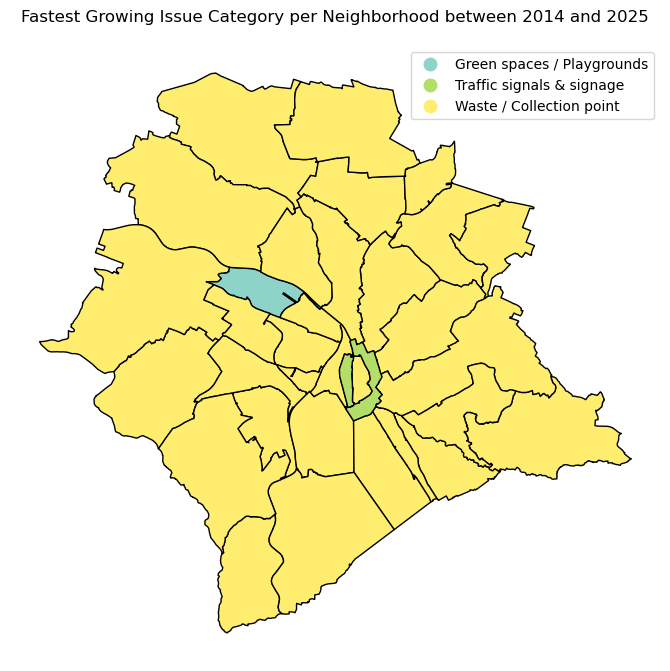

In [356]:
# map the top growth using the function
create_choropleth(
    gdf = fast_growing_issue_map,
    column = "service_name",
    title = "Fastest Growing Issue Category per Neighborhood between 2014 and 2025",
    legend_title = "Growing Issue",
    output_path = output_path_fast_growing_issue,
    cmap = "Set3"
)

We see, that Friesenberg has an increasing problem with waste, even though its most common issue are the green spaces/playgrounds. Contrary, for Escher Wyss, the increasing problem are the green spaces/playgrounds and the most common issue waste. Traffic signals are a common problem in Hochschulen and here we see that it is increasing fast for Hochschulen and also for Lindenhof.

### 7 Limitations and Improvements

This project is limited by the fact that the Züri wie neu dataset only includes issues reported by citizens, which may introduce reporting bias between neighborhoods. High report numbers may therefore reflect stronger citizen participation rather than objectively worse urban conditions. In addition, the analysis aggregates data at the neighborhood level, which can hide smaller local hotspots within neighborhoods. The study also mainly compares 2014 and 2025, meaning that short-term fluctuations and external influences are not fully captured. Another limitation is that broad issue categories may oversimplify more detailed urban problems. 

Future improvements could include hotspot analysis, spatial regression, or time-series analysis to better understand spatial and temporal dynamics. Text mining methods could also be applied to report descriptions to identify more specific issue patterns. On the technical side, the code could be improved through more modular functions. Interactive dashboards or web maps could further enhance the communication and usability of the results.

### 8 Conclusion

The analysis shows that citizen-reported urban issues in Zurich are unevenly distributed across neighborhoods and have changed considerably between 2014 and 2025. Central neighborhoods such as City and Hochschulen recorded the highest number of reports per capita, indicating particularly high urban pressure and intensive infrastructure use. In addition, several neighborhoods experienced a strong increase in the number of reports over time, especially Langstrasse and Altstetten, suggesting either growing reporting activity or an increase in urban challenges.

The analysis of issue categories shows that waste and collection points are the most frequently reported problems in most neighborhoods. However, the fastest-growing issue categories are not always the most common ones. For example, Friesenberg shows an increasing number of waste-related reports, even though green spaces and playgrounds currently represent the most common issue there. In contrast, Escher Wyss is currently dominated by waste-related reports, while green spaces and playgrounds are the fastest-growing category. Furthermore, traffic signals and signage are already common issues in Hochschulen and are also among the fastest-growing categories there and in Lindenhof.

Overall, Langstrasse recorded the highest number of reports, suggesting that it is the most frequently reported neighborhood in terms of urban issues. However, this may also be influenced by its higher population density and greater reporting activity. Therefore, City might be considered equally or even more problematic when adjusting for population size. Across Zurich, waste and collection point issues emerge as the most significant category overall and are also among the fastest increasing issues in many neighborhoods.